# Analyse des données DVF

## Initialisation

In [32]:
from io import BytesIO
from datetime import datetime
from dataclasses import dataclass, field
from typing import Optional
from functools import reduce
import operator
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import geopandas as gpd
# import contextily as ctx
import requests
from thefuzz import process
from IPython.display import display

In [33]:
@dataclass
class RemoteDataRetriever():
    """ télécharge les données dvf de data.gouv.fr pour une commune donnée """
    nom_commune: str
    _commune_trouvee: Optional[str] = field(default=None, init=False)
    _code_commune: Optional[str] = field(default=None, init=False)
        
    def get_remote_data(self, annee):
        """ télécharger les données pour une année """
        code_commune, departement = self.get_code_commune()
        url = fr"https://files.data.gouv.fr/geo-dvf/latest/csv/{annee}/communes/{departement}/{code_commune}.csv"
        # print(url)
        response = requests.get(url)
        bio = BytesIO(response.content)
        bio.seek(0)
        csv_data = pd.read_csv(bio)
        return csv_data

    def get_code_commune(self):
        """ déterminer le code commune à partir du nom """
        communes = pd.read_csv(r'cog_ensemble_2025_csv/v_commune_2025.csv')
        row_i = process.extractOne(self.nom_commune, communes['LIBELLE'])[2]
        row = communes.iloc[row_i]
        self._commune_trouvee = {
            'libellé': row['LIBELLE'],
            'code': row['COM'],
            'département': row['DEP'],
        }
        return row["COM"], row["DEP"]
    
    @property
    def commune_trouvee(self):
        return self._commune_trouvee

def iand(iterable):
    """ opère sur une liste d'itérables avec n éléments chacun.
    Effectue un ET sur chacun des n éléments. """
    return reduce(operator.iand, iterable, True)

## Paramètres

In [81]:
nom_commune = "Pessac"  # "PARIS 14E ARRONDISSEMENT"
annees = range(2022, 2026)  # attention, données dispo seulement depuis 2016

## Récupération des données

In [106]:
data_retriever = RemoteDataRetriever(nom_commune)
data = pd.DataFrame()
for annee in annees:
    data =  pd.concat([data, data_retriever.get_remote_data(annee=annee)], ignore_index=True)
    commune_trouvee = data_retriever.commune_trouvee
    print(f"Données téléchargées pour l'année {annee} pour la commune {commune_trouvee.get('libellé')} (code {commune_trouvee.get('code')}), département {commune_trouvee.get('département')}")
data = data[(data["valeur_fonciere"].notnull() & data["surface_reelle_bati"].notnull() & data["longitude"].notnull() & data["latitude"].notnull())]
data["valeur_surface"] = data.valeur_fonciere / data.surface_reelle_bati
data["date_mutation"] = pd.to_datetime(data["date_mutation"])
data = data.sort_values("date_mutation")

Données téléchargées pour l'année 2022 pour la commune Pessac (code 33318), département 33
Données téléchargées pour l'année 2023 pour la commune Pessac (code 33318), département 33
Données téléchargées pour l'année 2024 pour la commune Pessac (code 33318), département 33
Données téléchargées pour l'année 2025 pour la commune Pessac (code 33318), département 33


In [107]:
data

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,valeur_surface
22,2022-494919,2022-01-04,1,Vente,450000.0,98.0,NaN,AV DU GENERAL LECLERC,1470,33600.0,33318,Pessac,33,NaN,NaN,33318000HY0429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,155.0,6.0,S,sols,NaN,NaN,727.0,-0.674543,44.789845,2903.225806
21,2022-494915,2022-01-04,1,Vente,322000.0,5.0,NaN,ALL DES PALISSANDRES,2425,33600.0,33318,Pessac,33,NaN,NaN,33318000AY0088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,78.0,4.0,S,sols,NaN,NaN,263.0,-0.670744,44.804221,4128.205128
48,2022-495079,2022-01-04,1,Vente,160500.0,33.0,NaN,AV MARC DESBATS,2140,33600.0,33318,Pessac,33,NaN,NaN,33318000CX0109,NaN,NaN,6.0,46.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,49.0,2.0,NaN,NaN,NaN,NaN,NaN,-0.621754,44.804715,3275.510204
33,2022-495009,2022-01-05,1,Vente,154850.0,9.0,NaN,AV DES ACIERIES,0030,33600.0,33318,Pessac,33,NaN,NaN,33318000CT0191,NaN,NaN,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,34.0,1.0,NaN,NaN,NaN,NaN,NaN,-0.643601,44.801374,4554.411765
49,2022-495109,2022-01-06,1,Vente,663000.0,9.0,NaN,AV DE LA SOURCE,3100,33600.0,33318,Pessac,33,NaN,NaN,33318000DN0420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,165.0,7.0,S,sols,NaN,NaN,439.0,-0.621900,44.800959,4018.181818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10530,2025-400001,2025-12-30,1,Vente,251500.0,36.0,NaN,AV DES CHASSEURS,0850,33600.0,33318,Pessac,33,NaN,NaN,33318000DO0220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,77.0,3.0,S,sols,NaN,NaN,277.0,-0.621492,44.799294,3266.233766
10550,2025-400180,2025-12-30,1,Vente,265000.0,7.0,NaN,AV DE CHAMPAGNE,0753,33600.0,33318,Pessac,33,NaN,NaN,33318000EK0471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,85.0,4.0,S,sols,NaN,NaN,499.0,-0.684112,44.788929,3117.647059
10502,2025-399626,2025-12-31,1,Vente,1515400.0,26.0,NaN,AV LEONARD DE VINCI,2035,33600.0,33318,Pessac,33,NaN,NaN,33318000HH0099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.0,Local industriel. commercial ou assimilé,515.0,0.0,AB,terrains a bâtir,NaN,NaN,2169.0,-0.656784,44.781346,2942.524272
10501,2025-399626,2025-12-31,1,Vente,1515400.0,26.0,NaN,AV LEONARD DE VINCI,2035,33600.0,33318,Pessac,33,NaN,NaN,33318000HH0099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.0,Local industriel. commercial ou assimilé,140.0,0.0,AB,terrains a bâtir,NaN,NaN,2169.0,-0.656784,44.781346,10824.285714


## Filtres de données
Modifiez ci-dessous en fonction des besoins

In [115]:
filters = [
    data["type_local"] == 'Appartement',
    data["nature_mutation"] == 'Vente',
    data["valeur_surface"] < 8000,
    3000 < data["valeur_surface"],
    70 < data["surface_reelle_bati"],
    data["surface_reelle_bati"] < 130,
    #'2017' in data["id_mutation"]
]

In [116]:
fdata = data[iand(filters)]

# décommenter ci-dessous pour afficher les données filtrées et les colonnes disponibles
#pd.set_option('display.max_columns', None)
#display(fdata)

In [117]:
gfdata = gpd.GeoDataFrame(
    fdata, geometry=gpd.points_from_xy(fdata.longitude, fdata.latitude))
#gfdata.crs = "EPSG:4326"
# gfdata = gfdata.to_crs(epsg=3857)

In [118]:
#ax = gfdata.plot(figsize=(10, 5), alpha=0.5, edgecolor='k', aspect='equal')
#ctx.add_basemap(ax, crs='EPSG:4326', zoom=14, source=ctx.providers.OpenStreetMap.Mapnik)
#plt.show()

In [119]:
from ipyleaflet import Map, DrawControl, GeoData, LayersControl, MarkerCluster, CircleMarker

# centrer la carte sur le barycentre des données
centroid = gfdata.dissolve().centroid
m = Map(center=(centroid.y[0], centroid.x[0]), zoom=12)

draw_control = DrawControl(
    polygon={"shapeOptions": {"color": "#0000FF"}},
    polyline={},
    circle={},
    circlemarker={}
)

# le callback ci-dessous permet de modifier la liste features
# à chaque création ou suppression de polygones par l'utilisateur
features = []
# log = []
def handle_draw(target, action, geo_json):
    # log.append(action)
    if action == 'created':
        features.append(geo_json)
    elif action == 'deleted':
        # log.append('delete!')
        perform_delete = False
        for deleted_index, feature in enumerate(features):
            if geo_json['geometry'] == feature['geometry']:
                # log.append(f'delete {deleted_index}')
                perform_delete = True
                break
        if perform_delete:
            features.pop(deleted_index)

# handle_draw sera appelé à chaque action de dessin de polygone
draw_control.on_draw(handle_draw)

m.add_control(draw_control)
control = LayersControl(position='topright')
m.add_control(control)

marker_list = []
for feature in gfdata['geometry']:
    marker = CircleMarker(location=(feature.coords[0][1],feature.coords[0][0]),
                         radius = 1,
                          color = "red",
                          fill_color = "red"
                         )
    marker_list.append(marker)
    
marker_cluster = MarkerCluster(
    markers=(marker_list),
    name = 'first point'
)

m.add_layer(marker_cluster)
#print(m.layers)
m

Map(center=[np.float64(44.80082167123289), np.float64(-0.6474743150684932)], controls=(ZoomControl(options=['p…

In [122]:
selected_areas = gpd.GeoDataFrame.from_features(features)
#ax = selected_areas.plot(figsize=(10, 5), alpha=0.5, edgecolor='k', aspect='equal')
#ctx.add_basemap(ax, crs='EPSG:4326', zoom=14, source=ctx.providers.OpenStreetMap.Mapnik)
#plt.show()

# filter data based on selected areas
selected_markers = []
try:
    for selected_area in selected_areas['geometry']:
        selected_markers.append(gfdata['geometry'].within(selected_area))
    final_data_mask = pd.Series(np.logical_or.reduce(selected_markers))
    final_data_mask.index = gfdata.index

    geo_filtered_gfdata = gfdata[final_data_mask]
except KeyError:  # no area selected
    geo_filtered_gfdata = gfdata

Prix moyen au m2: 3836 €
Prix médian au m2: 3634 €


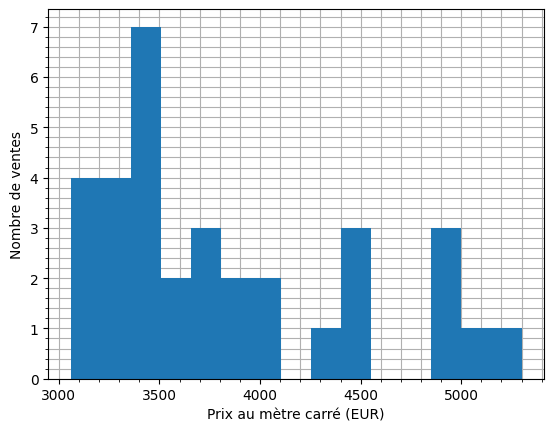

In [123]:
#last_year_mask = pd.Series(np.logical_or.reduce(selected_markers))
print(f'Prix moyen au m2: {np.mean(geo_filtered_gfdata.valeur_surface):.0f} €')
print(f'Prix médian au m2: {np.median(geo_filtered_gfdata.valeur_surface):.0f} €')
plt.figure()
plt.hist(geo_filtered_gfdata.valeur_surface, bins=15)
plt.xlabel("Prix au mètre carré (EUR)")
plt.ylabel("Nombre de ventes")
from matplotlib.ticker import AutoMinorLocator
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.grid(which='both')
plt.gca().set_axisbelow(True)
plt.show()

In [124]:
dates = geo_filtered_gfdata["date_mutation"]
valeurs = geo_filtered_gfdata["valeur_surface"]
valeurs_lissees = geo_filtered_gfdata.rolling(on="date_mutation", window="30D")["valeur_surface"].median()
linear_func = lambda x, m, p: m*x + p
fitted_curve, _ = curve_fit(linear_func, np.nan_to_num(dates.values.astype(np.int64)), np.nan_to_num(valeurs))
fitted_data = linear_func(dates.values.astype(np.int64), *fitted_curve)

Évolution de -8.2%
Valeur finale 3651 EUR


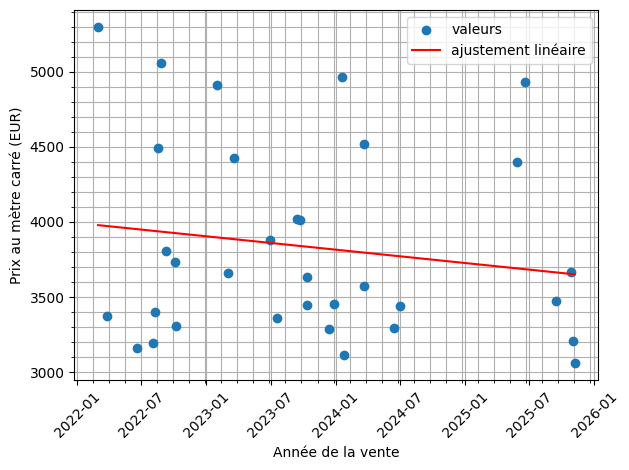

In [125]:
plt.figure()
plt.scatter(dates, valeurs, label='valeurs')
#plt.plot(dates, valeurs_lissees, label='valeurs lissées')
plt.plot(dates, fitted_data, 'r', label='ajustement linéaire')
#plt.ylim(0, 5000)
valeurs_lissees.head()
from matplotlib.ticker import AutoMinorLocator
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.grid(which='both')
plt.gca().set_axisbelow(True)
plt.legend()
plt.xlabel('Année de la vente')
plt.ylabel('Prix au mètre carré (EUR)')
plt.xticks(rotation = 45)
plt.tight_layout()
print(f'Évolution de {(fitted_data[-1] - fitted_data[0])/fitted_data[0] * 100:+.1f}%')
print(f'Valeur finale {fitted_data[-1]:.0f} EUR')
plt.show()

In [126]:
5000*73

365000

In [128]:
pd.options.display.max_columns = None
geo_filtered_gfdata[["date_mutation", "valeur_fonciere", "adresse_numero", "adresse_nom_voie", "surface_reelle_bati", "nombre_pieces_principales"]]


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,surface_reelle_bati,nombre_pieces_principales
448,2022-03-01,530000.00,167.0,AV DOCTEUR NANCEL PENARD,100.0,4.0
603,2022-03-25,260000.00,110.0,AV DOCTEUR NANCEL PENARD,77.0,4.0
1139,2022-06-20,227510.00,129.0,AV DOCTEUR NANCEL PENARD,72.0,4.0
1489,2022-08-03,242600.00,110.0,AV DOCTEUR NANCEL PENARD,76.0,4.0
1720,2022-08-08,245000.00,2.0,AV DE NOES,72.0,4.0
1796,2022-08-18,319000.00,105.0,AV DOCTEUR NANCEL PENARD,71.0,3.0
1890,2022-08-26,394710.00,65.0,AV LEON BLUM,78.0,3.0
1845,2022-09-08,400000.00,5.0,RUE PIERRE RAMBAUD,105.0,4.0
2310,2022-10-03,265000.00,104.0,AV DOCTEUR NANCEL PENARD,71.0,3.0
2353,2022-10-06,235000.00,18.0,AV PAUL MONTAGNE,71.0,3.0
